# D&D Combat Simulation with Monte Carlo Methods

## Overview

This project uses Python to simulate repeated Dungeons & Dragons-style
1v1 combat encounters and estimate the probability of each combatant winning.

The simulation models core combat mechanics including initiative, attack rolls,
Armor Class (AC), critical hits, damage rolls, and hit points.

The project also investigates how the number of simulated fights affects the
stability of the estimated win rate.

In [109]:
import matplotlib.pyplot as plt
import random
import pandas as pd


## Combatants

The simulation uses two configurable combatants. Character statistics are
stored in Python dictionaries, allowing attributes such as HP, AC, attack
bonus, damage dice, and initiative bonus to be easily modified.

For this analysis, Regnar Torsten, my friend's D&D cleric character, is tested against a [Dire Wolf](https://www.dndbeyond.com/monsters/16841-dire-wolf?srsltid=AU7gw4VrNvwNtL16VxDOAlpPsdYawra5TcVwZ8MQJy1JMxE70_JuH0uY). Regnar normally has access to spells, but this scenario assumes he has exhausted his spell slots and must rely entirely on his medium armor and greatsword. The simulation estimates his chances of surviving the encounter using only basic weapon attacks.

In [110]:
#stat for creature1
C_1 = {
    "name": "Regnar Torsten",
    "ac": 17,
    "hp": 26,
    "damage_dice_count": 2,
    "damage_die": 6,
    "damage_bonus": 4,
    "attack_bonus": 6,
    "initiative_bonus": 2
}


In [111]:
#stat for creature2
C_2 = {
    "name": "Dire Wolf",
    "ac": 14,
    "hp": 37,
    "damage_dice_count": 2,
    "damage_die": 6,
    "damage_bonus": 3,
    "attack_bonus": 5,
    "initiative_bonus": 2
}


In [112]:
# Quick comparison of combatant stats

combatant_comparison = pd.DataFrame({
    "Stat": [
        "AC",
        "HP",
        "Attack Bonus",
        "Average Damage",
        "Initiative Bonus"
    ],
    
    C_1["name"]: [
        C_1["ac"],
        C_1["hp"],
        C_1["attack_bonus"],
        C_1["damage_dice_count"] * ((C_1["damage_die"] + 1) / 2) + C_1["damage_bonus"],
        C_1["initiative_bonus"]
    ],
    
    C_2["name"]: [
        C_2["ac"],
        C_2["hp"],
        C_2["attack_bonus"],
        C_2["damage_dice_count"] * ((C_2["damage_die"] + 1) / 2) + C_2["damage_bonus"],
        C_2["initiative_bonus"]
    ]
})

combatant_comparison["Difference"] = (
    combatant_comparison[C_1["name"]] -
    combatant_comparison[C_2["name"]]
)

combatant_comparison

,Stat,Regnar Torsten,Dire Wolf,Difference
0,AC,17.0,14.0,3.0
1,HP,26.0,37.0,-11.0
2,Attack Bonus,6.0,5.0,1.0
3,Average Damage,11.0,10.0,1.0
4,Initiative Bonus,2.0,2.0,0.0


### Initial Comparison

The two combatants have relatively similar offensive stats. Regnar has a slightly higher attack bonus (+6 vs. +5) and average damage per successful hit (11 vs. 10), while both have the same +2 initiative bonus.

Their main difference is survivability: Regnar has 3 more AC, making him harder to hit, while the Dire Wolf has 11 more HP and can therefore absorb considerably more damage.

The simulation will test how these differences translate into actual win probability across repeated fights.

In [113]:
#Define functionalities here for DnD combat essentials
def roll_die(die_count, die_max):
    return sum(random.randint(1, die_max) for _ in range(die_count))

def attack(attacker, defender):
    raw_roll = roll_die(1, 20)
    total_roll = raw_roll + attacker["attack_bonus"]

    if raw_roll == 20:
        result = "Critical Hit"
    elif raw_roll == 1:
        result = "Miss"
    elif total_roll >= defender["ac"]:
        result = "Hit"
    else:
        result = "Miss"

    return raw_roll, total_roll, result

def damage(attacker, result):
    if result == "Miss":
        return 0

    elif result == "Hit":
        return (
            roll_die(
                attacker["damage_dice_count"],
                attacker["damage_die"]
            )
            + attacker["damage_bonus"]
        )

    elif result == "Critical Hit":
        return (
            roll_die(
                attacker["damage_dice_count"] * 2,
                attacker["damage_die"]
            )
            + attacker["damage_bonus"]
        )

def reduce_health(attacker, defender, result):
    damage_dealt = damage(attacker, result)
    defender["hp"] -= damage_dealt

    if defender["hp"] < 0:
        defender["hp"] = 0

    return damage_dealt

def roll_initiative(fighter1, fighter2):

    C1_init = roll_die(1, 20) + fighter1["initiative_bonus"]
    C2_init = roll_die(1, 20) + fighter2["initiative_bonus"]

    # Reroll ties
    while C1_init == C2_init:
        C1_init = roll_die(1, 20) + fighter1["initiative_bonus"]
        C2_init = roll_die(1, 20) + fighter2["initiative_bonus"]

    if C1_init > C2_init:
        first = fighter1
        second = fighter2
    else:
        first = fighter2
        second = fighter1

    return first, second, first["name"]



In [114]:
#define functions for simulation logs
def simulate_fight(C_1, C_2):

    # Create fresh copies for this fight
    fighter1 = C_1.copy()
    fighter2 = C_2.copy()
    # Log hit and misses of each creature
    fight_stats = {
    fighter1["name"]: {
        "hits": 0,
        "misses": 0,
        "crits": 0,
        "total_damage": 0
    },
    fighter2["name"]: {
        "hits": 0,
        "misses": 0,
        "crits": 0,
        "total_damage": 0
    }
}
    # Roll initiative
    first, second, initiative_winner = roll_initiative(fighter1, fighter2)

    # Start round counter
    round_number = 0

    # Combat
    while fighter1["hp"] > 0 and fighter2["hp"] > 0:

        round_number += 1

        # First creature attacks
        raw_roll, total_roll, result = attack(first, second)

        if result == "Hit":
            fight_stats[first["name"]]["hits"] += 1
        elif result == "Miss":
            fight_stats[first["name"]]["misses"] += 1
        elif result == "Critical Hit":
            fight_stats[first["name"]]["crits"] += 1

        damage_dealt = reduce_health(first, second, result)
        fight_stats[first["name"]]["total_damage"] += damage_dealt
        

        # Second creature attacks only if still alive
        if second["hp"] > 0:

            raw_roll, total_roll, result = attack(second, first)

            if result == "Hit":
                fight_stats[second["name"]]["hits"] += 1
            elif result == "Miss":
                fight_stats[second["name"]]["misses"] += 1
            elif result == "Critical Hit":
                fight_stats[second["name"]]["crits"] += 1

            damage_dealt = reduce_health(second, first, result)
            fight_stats[second["name"]]["total_damage"] += damage_dealt

    # Determine winner
    if fighter1["hp"] > 0:
        winner = fighter1["name"]
    else:
        winner = fighter2["name"]

    # Return one row of simulation results
    return {
        "winner": winner,
        "initiative_winner": initiative_winner,
        "total_rounds": round_number,

        fighter1["name"] + " Final HP": fighter1["hp"],
        fighter2["name"] + " Final HP": fighter2["hp"],

        fighter1["name"] + " Hits": fight_stats[fighter1["name"]]["hits"],
        fighter1["name"] + " Misses": fight_stats[fighter1["name"]]["misses"],
        fighter1["name"] + " Crits": fight_stats[fighter1["name"]]["crits"],
        fighter1["name"] + " Total Damage": fight_stats[fighter1["name"]]["total_damage"],

        fighter2["name"] + " Hits": fight_stats[fighter2["name"]]["hits"],
        fighter2["name"] + " Misses": fight_stats[fighter2["name"]]["misses"],
        fighter2["name"] + " Crits": fight_stats[fighter2["name"]]["crits"],
        fighter2["name"] + " Total Damage": fight_stats[fighter2["name"]]["total_damage"]
    }

In [115]:
def run_simulations(C_1, C_2, number_of_simulations):

    simulation_results = []

    for i in range(number_of_simulations):
        result = simulate_fight(C_1, C_2)
        simulation_results.append(result)

    simulation_df = pd.DataFrame(simulation_results)

    simulation_df.insert(
        0,
        "fight_id",
        range(1, len(simulation_df) + 1)
    )

    return simulation_df

simulation_100 = run_simulations(C_1, C_2, 100)
simulation_1000 = run_simulations(C_1, C_2, 1000)
simulation_10000 = run_simulations(C_1, C_2, 10000)
simulation_100000 = run_simulations(C_1, C_2, 100000)

In [116]:
def summarize_simulation(simulation_df, C_1, C_2):

    C1_name = C_1["name"]
    C2_name = C_2["name"]

    # ==========================================
    # TOTAL FIGHTS
    # ==========================================

    total_fights = len(simulation_df)

    print("TOTAL FIGHTS:", total_fights)
    print()


    # ==========================================
    # WINS / WIN RATE
    # ==========================================

    win_counts = simulation_df["winner"].value_counts()

    print("TOTAL WINS")
    print(win_counts)
    print()


    win_rates = simulation_df["winner"].value_counts(normalize=True) * 100

    print("WIN RATE (%)")
    print(win_rates.round(2))
    print()


    # ==========================================
    # AVERAGE NUMBER OF ROUNDS
    # ==========================================

    average_rounds = simulation_df["total_rounds"].mean()

    print("AVERAGE ROUNDS:", round(average_rounds, 2))
    print()


    # ==========================================
    # CREATURE 1
    # ==========================================

    C1_avg_hits = simulation_df[C1_name + " Hits"].mean()
    C1_avg_misses = simulation_df[C1_name + " Misses"].mean()
    C1_avg_crits = simulation_df[C1_name + " Crits"].mean()
    C1_avg_damage = simulation_df[C1_name + " Total Damage"].mean()

    print(C1_name.upper())
    print("Average Hits:", round(C1_avg_hits, 2))
    print("Average Misses:", round(C1_avg_misses, 2))
    print("Average Crits:", round(C1_avg_crits, 2))
    print("Average Total Damage:", round(C1_avg_damage, 2))
    print()


    # ==========================================
    # CREATURE 2
    # ==========================================

    C2_avg_hits = simulation_df[C2_name + " Hits"].mean()
    C2_avg_misses = simulation_df[C2_name + " Misses"].mean()
    C2_avg_crits = simulation_df[C2_name + " Crits"].mean()
    C2_avg_damage = simulation_df[C2_name + " Total Damage"].mean()

    print(C2_name.upper())
    print("Average Hits:", round(C2_avg_hits, 2))
    print("Average Misses:", round(C2_avg_misses, 2))
    print("Average Crits:", round(C2_avg_crits, 2))
    print("Average Total Damage:", round(C2_avg_damage, 2))
    print()


    # ==========================================
    # AVERAGE FINAL HP WHEN WINNING
    # ==========================================

    C1_wins = simulation_df[
        simulation_df["winner"] == C1_name
    ]

    C2_wins = simulation_df[
        simulation_df["winner"] == C2_name
    ]

    C1_avg_winning_hp = C1_wins[
        C1_name + " Final HP"
    ].mean()

    C2_avg_winning_hp = C2_wins[
        C2_name + " Final HP"
    ].mean()

    print("AVERAGE FINAL HP WHEN WINNING")
    print(C1_name + ":", round(C1_avg_winning_hp, 2))
    print(C2_name + ":", round(C2_avg_winning_hp, 2))

print("========== 100 SIMULATIONS ==========")
summarize_simulation(simulation_100, C_1, C_2)

print("\n========== 1,000 SIMULATIONS ==========")
summarize_simulation(simulation_1000, C_1, C_2)

print("\n========== 10,000 SIMULATIONS ==========")
summarize_simulation(simulation_10000, C_1, C_2)


========== 100 SIMULATIONS ==========
TOTAL FIGHTS: 100

TOTAL WINS
winner
Regnar Torsten    58
Dire Wolf         42
Name: count, dtype: int64

WIN RATE (%)
winner
Regnar Torsten    58.0
Dire Wolf         42.0
Name: proportion, dtype: float64

AVERAGE ROUNDS: 4.79

REGNAR TORSTEN
Average Hits: 2.86
Average Misses: 1.54
Average Crits: 0.15
Average Total Damage: 34.0

DIRE WOLF
Average Hits: 1.89
Average Misses: 2.4
Average Crits: 0.18
Average Total Damage: 21.81

AVERAGE FINAL HP WHEN WINNING
Regnar Torsten: 11.31
Dire Wolf: 15.07

========== 1,000 SIMULATIONS ==========
TOTAL FIGHTS: 1000

TOTAL WINS
winner
Regnar Torsten    539
Dire Wolf         461
Name: count, dtype: int64

WIN RATE (%)
winner
Regnar Torsten    53.9
Dire Wolf         46.1
Name: proportion, dtype: float64

AVERAGE ROUNDS: 4.71

REGNAR TORSTEN
Average Hits: 2.68
Average Misses: 1.56
Average Crits: 0.2
Average Total Damage: 33.1

DIRE WOLF
Average Hits: 1.78
Average Misses: 2.4
Average Crits: 0.22
Average Total Damage:

## Experiment 1: Effect of Simulation Size

The first experiment compares estimated combat outcomes using progressively
larger numbers of simulated fights. Win Rate of Combatant_1 (Regnar) is used for testing.

In [117]:
def get_comparison_metrics(simulation_df, C_1, C_2):

    C1_name = C_1["name"]
    C2_name = C_2["name"]

    total_fights = len(simulation_df)

    C1_win_rate = (
        (simulation_df["winner"] == C1_name).mean() * 100
    )

    C2_win_rate = (
        (simulation_df["winner"] == C2_name).mean() * 100
    )

    avg_rounds = simulation_df["total_rounds"].mean()

    C1_avg_damage = simulation_df[
        C1_name + " Total Damage"
    ].mean()

    C2_avg_damage = simulation_df[
        C2_name + " Total Damage"
    ].mean()

    return {
        "Simulations": total_fights,
        C1_name + " Win Rate": round(C1_win_rate, 2),
        C2_name + " Win Rate": round(C2_win_rate, 2),
        "Avg Rounds": round(avg_rounds, 2),
        C1_name + " Avg Damage": round(C1_avg_damage, 2),
        C2_name + " Avg Damage": round(C2_avg_damage, 2)
    }

comparison_results = [
    get_comparison_metrics(simulation_100, C_1, C_2),
    get_comparison_metrics(simulation_1000, C_1, C_2),
    get_comparison_metrics(simulation_10000, C_1, C_2),
    get_comparison_metrics(simulation_100000, C_1, C_2)
]
comparison_df = pd.DataFrame(comparison_results)

comparison_df["Win Rate Change"] = (
    comparison_df[C_1["name"] + " Win Rate"]
    .diff()
    .abs()
)

comparison_df

,Simulations,Regnar Torsten Win Rate,Dire Wolf Win Rate,Avg Rounds,Regnar Torsten Avg Damage,Dire Wolf Avg Damage,Win Rate Change
0,100,58.00,42.00,4.79,34.00,21.81,NaN
1,1000,53.90,46.10,4.71,33.10,21.37,4.10
2,10000,55.81,44.19,4.71,33.30,21.38,1.91
3,100000,55.93,44.07,4.70,33.37,21.32,0.12


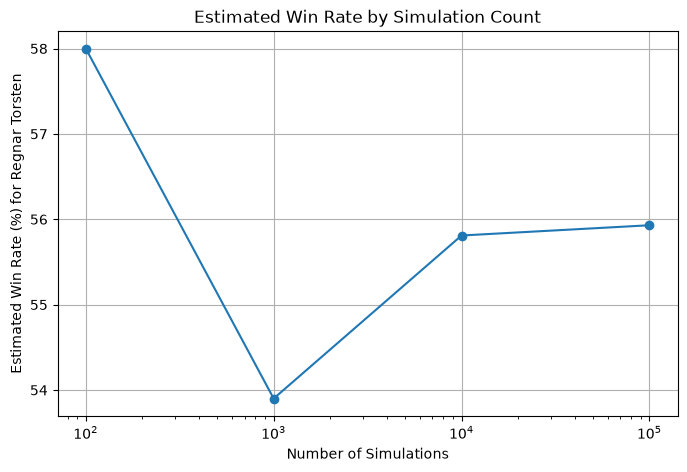

In [118]:
plt.figure(figsize=(8, 5))

plt.plot(
    comparison_df["Simulations"],
    comparison_df[C_1["name"] + " Win Rate"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Number of Simulations")
plt.ylabel("Estimated Win Rate (%) for " + C_1["name"])
plt.title("Estimated Win Rate by Simulation Count")
plt.grid(True)
plt.show()

### Initial Simulation Size Comparison

As an initial test, the combat simulation was run once at four different
sample sizes: 100, 1,000, 10,000, and 100,000 fights.

The estimated win rate varied noticeably at smaller sample sizes, from 58.0% at 100 simulations to 53.9% at 1,000 simulations. At larger sample sizes, the estimates became much closer, with the 10,000 and 100,000 simulation runs both producing estimates near 56%.

However, because each sample size was tested only once, these results alone
are not sufficient to determine whether the estimates are consistently stable.

To test this more reliably, each simulation size is repeated multiple times
in the following analysis.

## Experiment 2: Stability Across Repeated Runs

Because each result in the first experiment came from only one random sample,
a second experiment tests whether the estimated win rate remains consistent
when the same simulation size is repeated independently.

Each simulation size is therefore run 10 separate times.

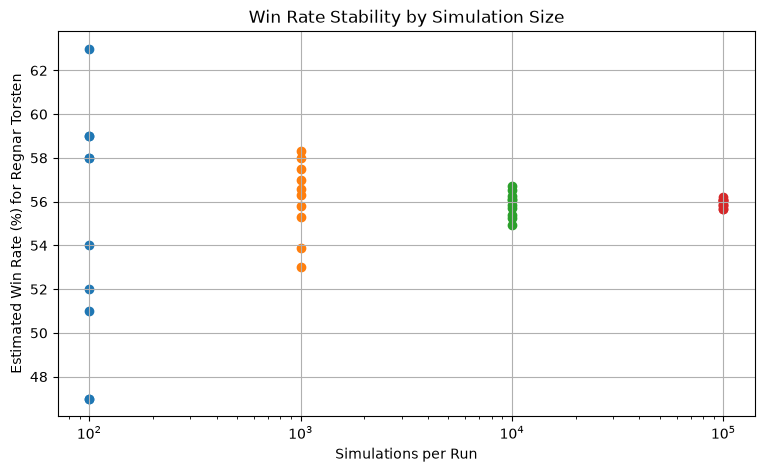

In [119]:
#running each simulation counts again 10 times each
simulation_counts = [100, 1000, 10000, 100000]

stability_results = []

for sim_count in simulation_counts:

    for i in range(10):

        # Run simulation
        test_df = run_simulations(C_1, C_2, sim_count)

        # Calculate C1 win rate
        win_rate = (
            (test_df["winner"] == C_1["name"]).mean() * 100
        )

        # Store result
        stability_results.append({
            "Simulations": sim_count,
            "Run": i + 1,
            "Win Rate": win_rate
        })


# Turn results into DataFrame
stability_df = pd.DataFrame(stability_results)

plt.figure(figsize=(9, 5))

for sim_count in simulation_counts:

    data = stability_df[
        stability_df["Simulations"] == sim_count
    ]

    plt.scatter(
        [sim_count] * len(data),
        data["Win Rate"]
    )

plt.xscale("log")

plt.xlabel("Simulations per Run")
plt.ylabel("Estimated Win Rate (%) for " + C_1["name"])
plt.title("Win Rate Stability by Simulation Size")

plt.grid(True)

plt.show()

### Simulation Stability

To evaluate the stability of the Monte Carlo estimate, each simulation size
was repeated 10 times independently.

Smaller simulations produced substantial variation in the estimated win rate,
while larger simulations produced increasingly consistent estimates. At
100,000 fights per run, the estimated win rate clustered tightly around 56%.

Based on this stability, 100,000 simulations per scenario was selected for
subsequent analysis.

## Conclusion

The results demonstrate the effect of sample size on Monte Carlo simulation
stability. Small simulation samples produced substantial variation in the
estimated win rate between independent runs, while larger samples produced
increasingly consistent estimates.

At 100,000 simulated fights per run, the estimated win rate remained tightly
clustered across repeated experiments. Based on this result, 100,000
simulations per scenario provides a sufficiently stable baseline for further
combat analysis.

### Future Work

The simulator can be extended into a sensitivity analysis to investigate
questions such as:

- How do AC and HP affect survivability, combat duration, and win probability?
- How much does attack bonus affect hit rate and win probability?
- How strongly does initiative influence combat outcomes?
- With the same attack and damage bonuses, does damage distribution (such as 2d6 vs. 1d12) meaningfully affect average damage or win probability?
- How strongly are critical hits associated with winning an encounter?

Additional D&D mechanics such as advantage/disadvantage, multiple attacks,
spells, class abilities, and conditions could also be incorporated into
future versions.